In [29]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42	
import numpy as np
import pandas as pd
import seaborn as sns
DATA_PATH = '~/workspace/vllm/examples/imbalance'
PDF_PATH = '~/workspace/vllm/examples/results/pdf'
colors = [
  "#1F77B4",  # 蓝色
  "#FF7F0E",  # 橙色
  "#2CA02C",  # 绿色
  "#D62728",  # 红色
  "#9467BD",  # 紫色
  "#8C564B",  # 棕色
  "#E377C2",  # 粉色
  "#7F7F7F",  # 灰色
  "#17BECF",  # 青色
  "#BCBD22"   # 黄色
]

In [54]:
def plot_distribution(csv_path, pdf_path):
    df = pd.read_csv(csv_path)
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax1 = fig.add_subplot(111)
    ax2 = ax1.twinx()

    # ax1.plot(df['GPU KV cache usage'], label='GPU KV cache usage', color=plt.cm.Dark2(5/6), linestyle='--')
    # ax1.set_ylabel('KV cache usage (%)', color=plt.cm.Dark2(5/6))
    # ax1.tick_params(axis='y', labelcolor=plt.cm.Dark2(5/6))

    # ax2.plot(df['Running'], label='Running', color=plt.cm.Dark2(7/6), linestyle='-.')
    # ax2.set_ylabel('# of Running Requests', color=plt.cm.Dark2(7/6))
    # ax2.tick_params(axis='y', labelcolor=plt.cm.Dark2(7/6))

    sns.lineplot(data=df, x=df.index, y='GPU KV cache usage', ax=ax1, color=plt.cm.tab20b(0), linestyle='--')
    sns.lineplot(data=df, x=df.index, y='Running', ax=ax2, color=plt.cm.tab20b(4), linestyle='-.')
    # 绘制阴影
    ax1.fill_between(df.index, df['GPU KV cache usage'], color=plt.cm.tab20b(0), alpha=0.2)
    ax2.fill_between(df.index, df['Running'], color=plt.cm.tab20b(4), alpha=0.2)
    ax1.set_ylabel('KV cache usage (%)', color=plt.cm.tab20b(0))
    ax2.set_ylabel('# of Running Requests', color=plt.cm.tab20b(4))
    ax1.tick_params(axis='y', labelcolor=plt.cm.tab20b(0))
    ax2.tick_params(axis='y', labelcolor=plt.cm.tab20b(4))

    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # 设置x轴标签    
    ax1.set_xlabel('Time (s)')
    ax1.grid(True, axis='y', linestyle='-.', linewidth=0.5, alpha=0.5)
    # ax2.grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.tight_layout(pad=0, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'/home/wychen/workspace/vllm-dynamic/examples/results/pdf/imbalance_gpu_usage_requests.pdf')
    plt.show()

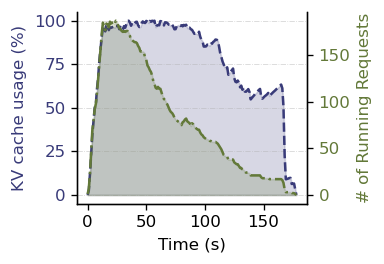

In [55]:
csv_apth = f'{DATA_PATH}/50.0qps-Llama-2-13b-chat-hf-170819-fcfs.csv'
plot_distribution(csv_apth, PDF_PATH)